# LargeDatasetTrain Visual Check

This notebook visualizes random samples from `large_dataset` as returned by `src.datasets.cosmic.LargeDatasetTrain`: target image, reference image, prompt, and the bboxes that go into training.

In [7]:
from pathlib import Path
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw

REPO_ROOT = Path('/home/kolyangg/rsrch/diffusion_template')
DATASET_FULL_ROOT = Path('/home/kolyangg/rsrch/dataset_full')
DATA_JSON = DATASET_FULL_ROOT / 'filtered_ids3_adj.json'
IMAGES_ROOT = DATASET_FULL_ROOT / 'large_dataset_adj/large_dataset'

NUM_REFS = 1
TRAIN_ON_SEPARATE_IMAGE = True
RANDOM_SAMPLE_COUNT = 8
BASE_SEED = 4321

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('repo:', REPO_ROOT)
print('json:', DATA_JSON)
print('images:', IMAGES_ROOT)
print('train_on_separate_image:', TRAIN_ON_SEPARATE_IMAGE)

repo: /home/kolyangg/rsrch/diffusion_template
json: /home/kolyangg/rsrch/dataset_full/filtered_ids3_adj.json
images: /home/kolyangg/rsrch/dataset_full/large_dataset_adj/large_dataset
train_on_separate_image: True


In [8]:
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf

from src.datasets.cosmic import LargeDatasetTrain
from src.datasets.collate import collate_fn

with initialize_config_dir(version_base=None, config_dir=str(REPO_ROOT / 'src/configs')):
    cfg = compose(
        config_name='one_id_09Feb_testing',
        overrides=[
            'datasets=all_datasets',
            'train_dataset_name=large_dataset',
            f'datasets.train.large_dataset.num_refs={NUM_REFS}',
            f'train_on_separate_image={str(TRAIN_ON_SEPARATE_IMAGE).lower()}',
            'val_datasets_names=[]',
        ],
    )

instance_transforms = instantiate(cfg.transforms.instance_transforms.train)
ds_cfg = OmegaConf.to_container(cfg.datasets.train.large_dataset, resolve=True)
ds_cfg.pop('_target_', None)
ds_cfg['data_json_pth'] = str(DATA_JSON)
ds_cfg['images_path'] = str(IMAGES_ROOT)
ds_cfg['num_refs'] = NUM_REFS
ds_cfg['train_on_separate_image'] = TRAIN_ON_SEPARATE_IMAGE
ds_cfg['instance_transforms'] = instance_transforms

ds = LargeDatasetTrain(**ds_cfg)
print('LargeDatasetTrain length:', len(ds))
print('num_refs:', NUM_REFS)
print('transforms:', instance_transforms)

100%|██████████| 2561/2561 [00:00<00:00, 176123.77it/s]

LargeDatasetTrain length: 47500
num_refs: 1
transforms: {'pixel_values': Compose(
      Resize(size=[1024, 1024], interpolation=bilinear, max_size=None, antialias=True)
      ToTensor()
      Normalize(mean=[0.5], std=[0.5])
)}


In [9]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def get_item(idx, seed=BASE_SEED):
    seed_everything(seed + idx)
    return ds[idx]


def tensor_or_pil_to_image(x):
    if isinstance(x, Image.Image):
        return x.convert('RGB')
    if torch.is_tensor(x):
        t = x.detach().cpu()
        if t.ndim == 4:
            t = t[0]
        if t.ndim == 3 and t.shape[0] in (1, 3):
            t = (t.float() * 0.5 + 0.5).clamp(0, 1)
            if t.shape[0] == 1:
                t = t.repeat(3, 1, 1)
            arr = (t.permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)
            return Image.fromarray(arr)
    raise TypeError(f'Unsupported image type: {type(x)}')


def as_bbox_list(value):
    if value is None:
        return []
    if torch.is_tensor(value):
        value = value.detach().cpu().tolist()
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)) and len(value) == 4 and all(isinstance(v, (int, float, np.number)) for v in value):
        return [list(map(float, value))]
    return [list(map(float, bbox)) for bbox in value]


def draw_bboxes(image, bboxes, labels=None, colors=None, width=5):
    img = tensor_or_pil_to_image(image).copy()
    draw = ImageDraw.Draw(img)
    bboxes = as_bbox_list(bboxes)
    labels = labels or [None] * len(bboxes)
    colors = colors or ['red', 'lime', 'cyan', 'yellow']
    for i, bbox in enumerate(bboxes):
        x0, y0, x1, y1 = bbox
        color = colors[i % len(colors)]
        draw.rectangle([x0, y0, x1, y1], outline=color, width=width)
        if labels[i]:
            draw.rectangle([x0, max(0, y0 - 22), x0 + 10 + 8 * len(labels[i]), y0], fill=color)
            draw.text((x0 + 4, max(0, y0 - 20)), labels[i], fill='black')
    return img


def dataset_path(idx):
    return ds.ids[idx]


def show_item(idx, seed=BASE_SEED):
    item = get_item(idx, seed=seed)
    refs = item['ref_images'] if isinstance(item['ref_images'], (list, tuple)) else [item['ref_images']]
    ref_bboxes = as_bbox_list(item.get('face_bbox_ref'))

    print(f'idx={idx}')
    print('path:', dataset_path(idx))
    print('identity:', ds.identity_by_path.get(dataset_path(idx)))
    print('prompt:', item.get('prompt') or item.get('prompts'))
    print('pixel_values:', tuple(item['pixel_values'].shape) if torch.is_tensor(item['pixel_values']) else type(item['pixel_values']))
    print('face_bbox:', item.get('face_bbox'))
    print('face_bbox_ref:', item.get('face_bbox_ref'))
    print('ref image sizes:', [r.size if isinstance(r, Image.Image) else tuple(r.shape) for r in refs])
    print('keys:', sorted(item.keys()))

    ncols = 1 + len(refs)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 5), squeeze=False)
    axes = axes[0]
    axes[0].imshow(draw_bboxes(item['pixel_values'], item['face_bbox'], labels=['target face'], colors=['red']))
    axes[0].set_title(f'target idx={idx}')
    axes[0].axis('off')
    for j, ref in enumerate(refs):
        bbox = ref_bboxes[j] if j < len(ref_bboxes) else None
        ref_vis = draw_bboxes(ref, bbox, labels=[f'ref {j} face'], colors=['lime']) if bbox is not None else tensor_or_pil_to_image(ref)
        axes[j + 1].imshow(ref_vis)
        axes[j + 1].set_title(f'ref {j}')
        axes[j + 1].axis('off')
    fig.suptitle(f'{dataset_path(idx)}\n{item.get("prompt") or item.get("prompts")}', fontsize=10)
    plt.tight_layout()
    plt.show()
    return item


rng = random.Random(BASE_SEED)
random_indices = rng.sample(range(len(ds)), k=min(RANDOM_SAMPLE_COUNT, len(ds)))
print('random indices:', random_indices)

random indices: [16664, 3657, 26707, 4163, 11597, 42015, 23948, 7436]


## Random 8 Samples

idx=16664
path: nm0001459/180.jpg
identity: nm0001459
prompt: The person img at the center has spiky blonde hair, wears a black leather jacket, and sports a silver chain necklace. Their expression appears serious and focused. They stand upright, hands slightly raised, with others around. The setting seems to be indoors, possibly a dimly lit room with a rustic backdrop.
pixel_values: (3, 1024, 1024)
face_bbox: [429, 111, 565, 284]
face_bbox_ref: [352, 213, 614, 536]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


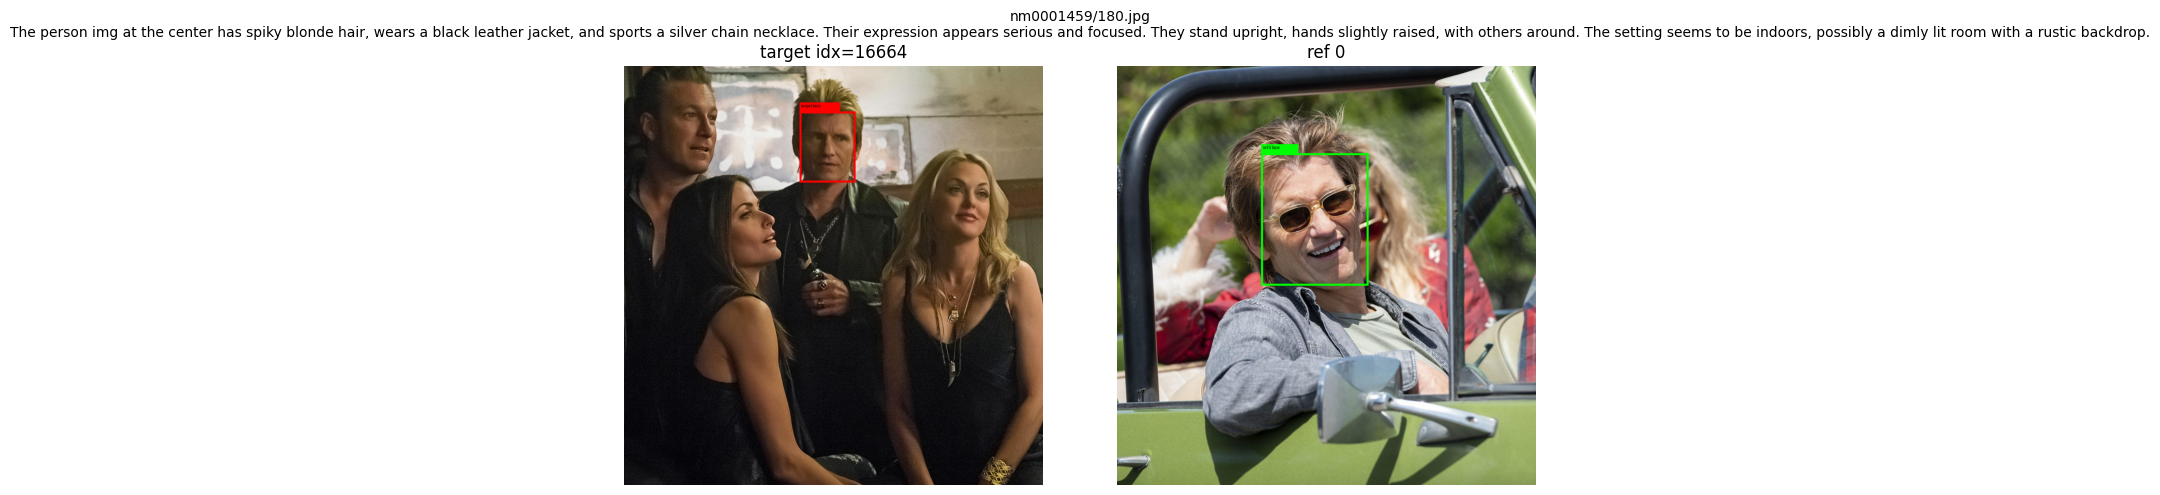

idx=3657
path: nm0000531/246.jpg
identity: nm0000531
prompt: A woman img with short brown hair peeks through a partially open door. She wears a blue jumpsuit and has a concerned expression. Her body is slightly turned, revealing only her profile. The setting appears to be a house exterior with green siding and a decorative wreath on the wall.
pixel_values: (3, 1024, 1024)
face_bbox: [400, 75, 534, 316]
face_bbox_ref: [346, 197, 540, 429]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


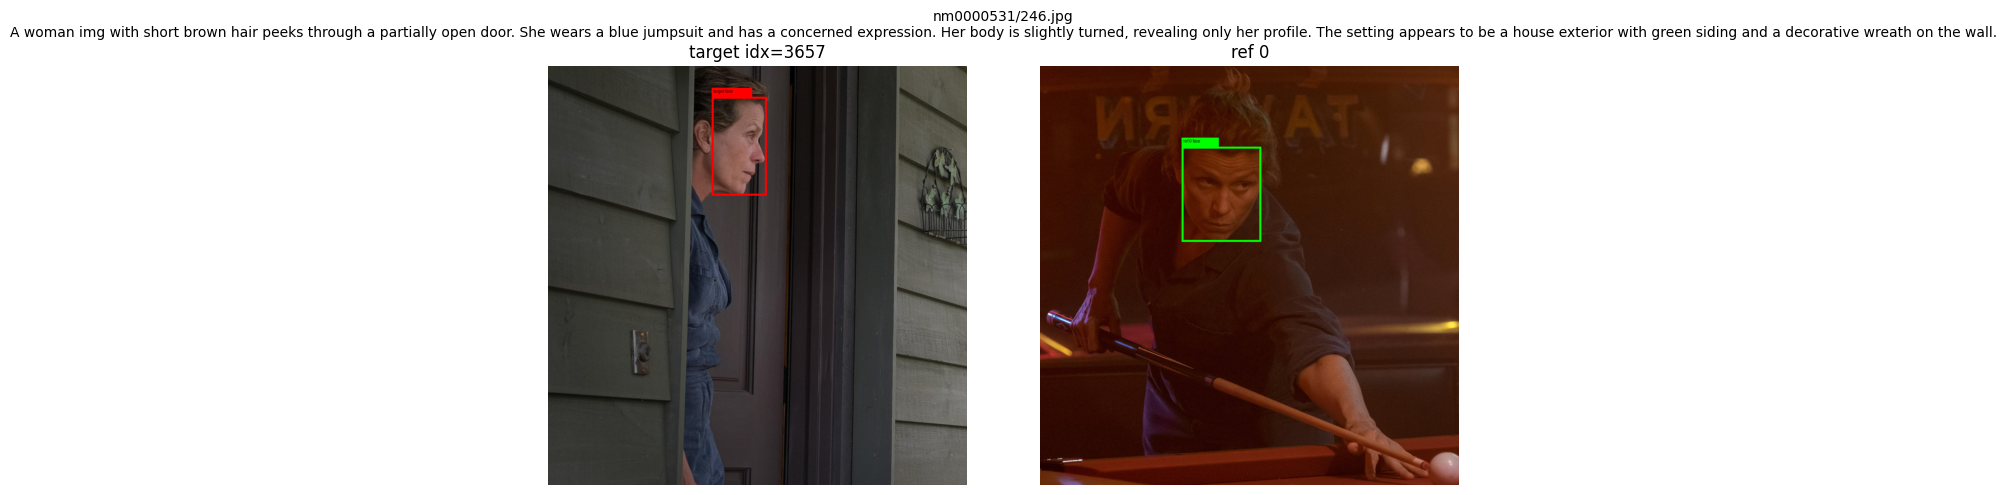

idx=26707
path: nm0004936/184.jpg
identity: nm0004936
prompt: Blonde-haired person img with short, styled hair wears a dark blue jacket over a light blue shirt. They have a slight smile and a relaxed demeanor. The background is a textured maroon wall. Their posture is upright, facing forward, exuding a casual yet composed vibe. No other people are prominently visible.
pixel_values: (3, 1024, 1024)
face_bbox: [362, 123, 627, 519]
face_bbox_ref: [402, 115, 727, 574]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


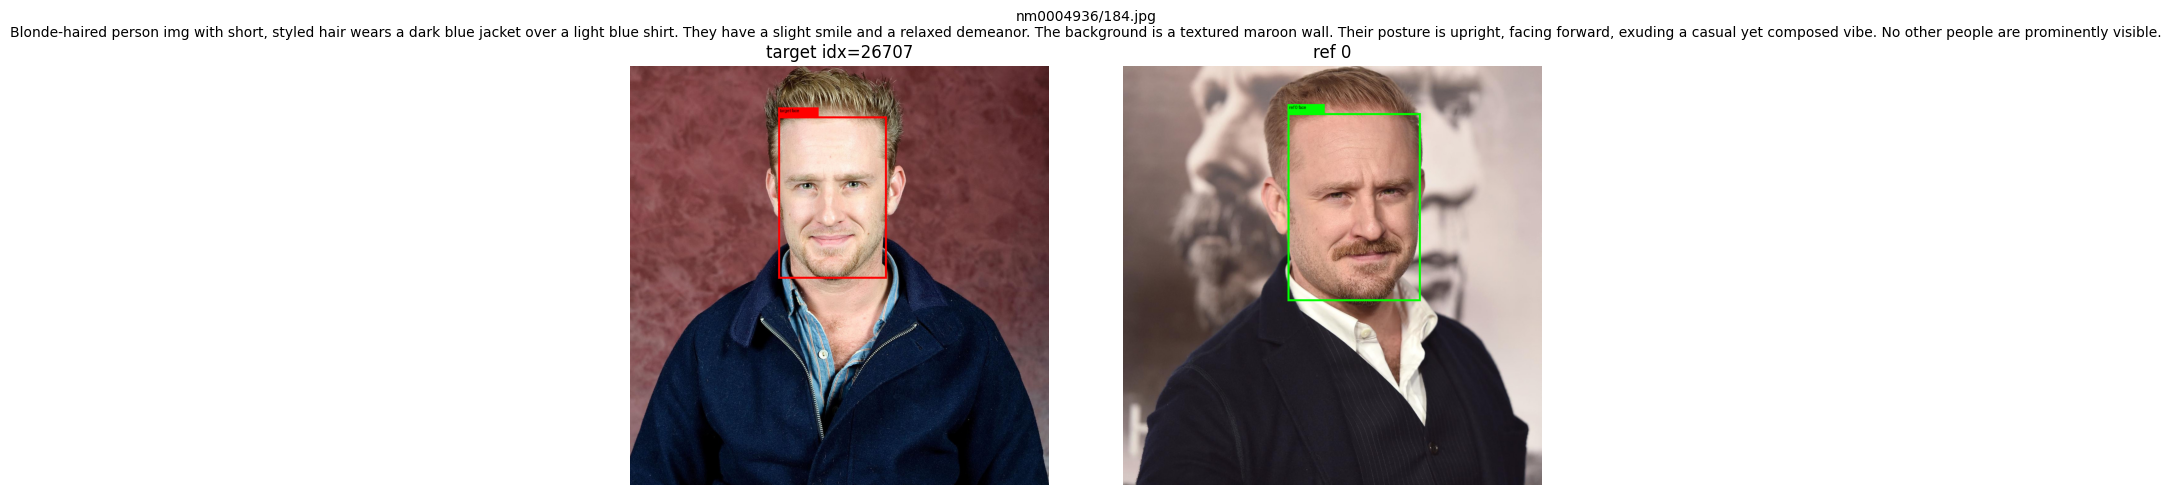

idx=4163
path: nm0000333/326.jpg
identity: nm0000333
prompt: The person img sports voluminous black curly hair framing a poised face with subtle makeup. They wear a beige jacket over a black top, exuding confidence. Their expression is calm and composed, with a slight smile. The background features a red banner with text, suggesting an event setting. Other figures are faintly visible behind.
pixel_values: (3, 1024, 1024)
face_bbox: [397, 365, 644, 753]
face_bbox_ref: [608, 51, 759, 319]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


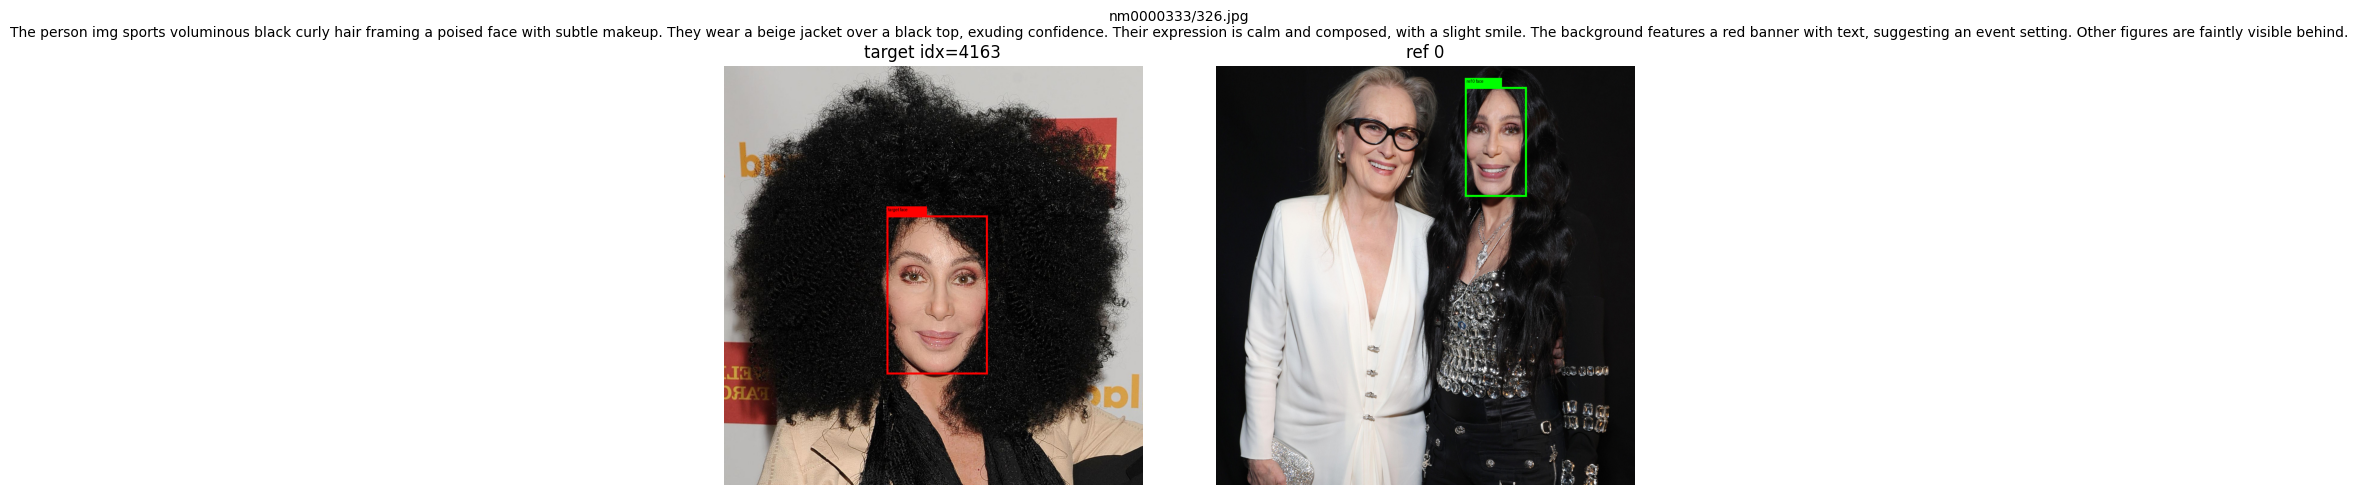

idx=11597
path: nm0000060/126.jpg
identity: nm0000060
prompt: A man img with neatly combed dark hair, wearing a casual shirt, sits outdoors on grass, smiling warmly. He interacts affectionately with a white dog beside him. His relaxed posture suggests comfort and joy. The background features trees and foliage, creating a serene park-like setting. His expression conveys happiness and contentment.
pixel_values: (3, 1024, 1024)
face_bbox: [360, 137, 512, 345]
face_bbox_ref: [257, 165, 690, 652]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


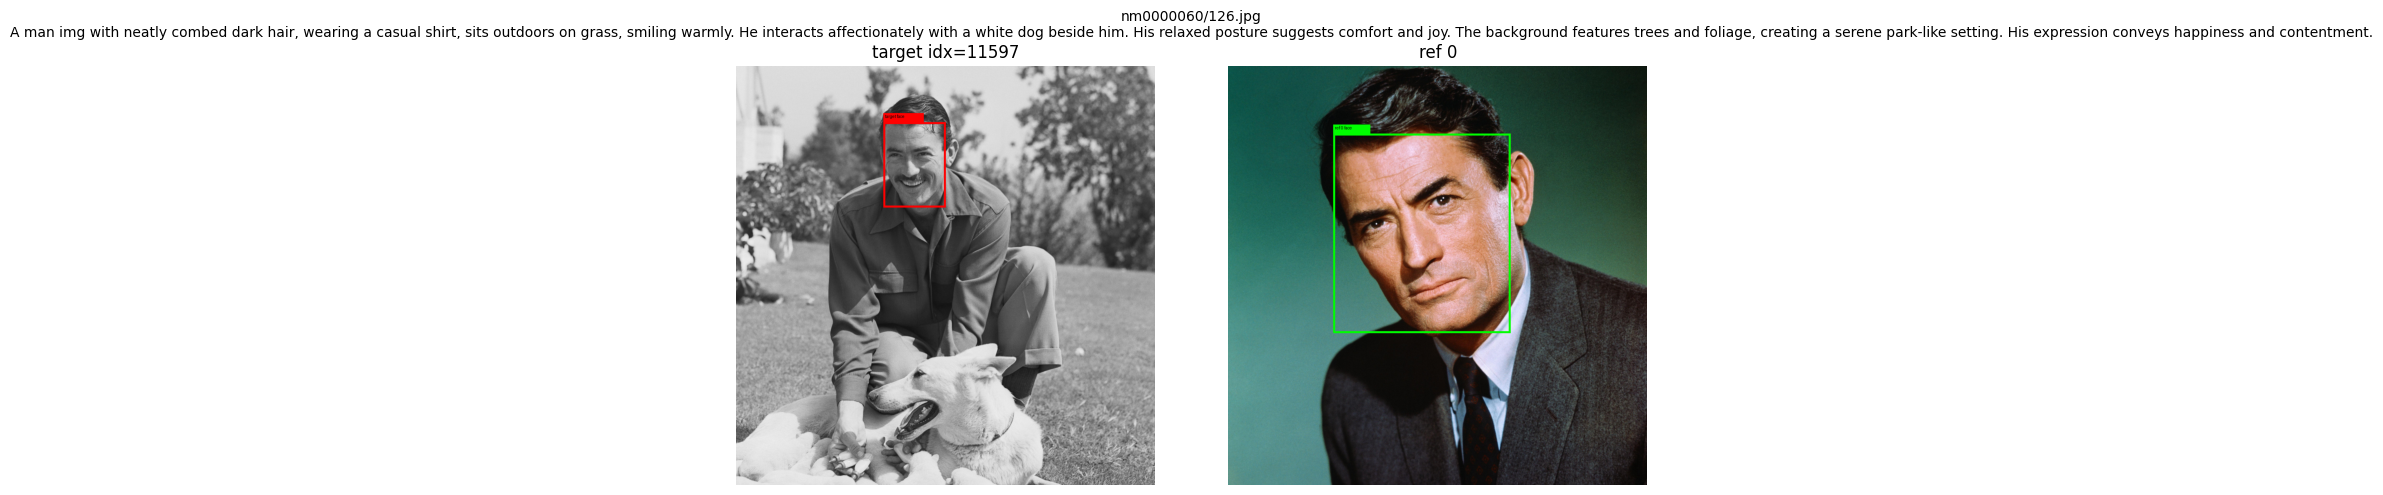

idx=42015
path: nm1617685/423.jpg
identity: nm1617685
prompt: A woman img with long black hair and bangs wears a blue sequined dress. Her neutral expression suggests calmness. She stands confidently, facing forward. In the background, blurred figures hint at a public event or gathering. Her earrings add a touch of elegance to her poised demeanor.
pixel_values: (3, 1024, 1024)
face_bbox: [286, 267, 618, 656]
face_bbox_ref: [377, 177, 639, 524]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


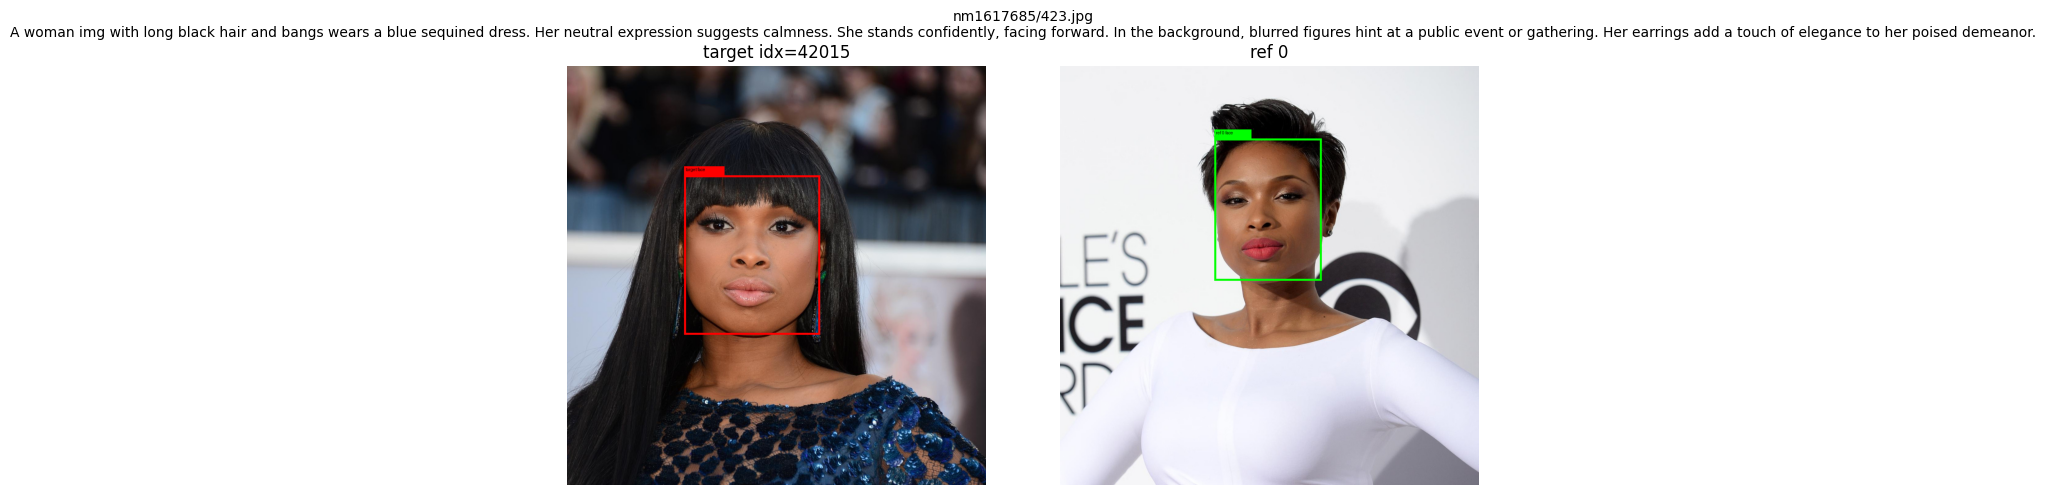

idx=23948
path: nm0001952/80.jpg
identity: nm0001952
prompt: The man, img with short gray hair and a beard, wears a brown jacket over a white shirt. His serious expression suggests concentration as he leans forward, examining a map on a lit table. Others stand nearby, observing. The setting appears to be a dimly lit room with wooden panels and modern lighting fixtures.
pixel_values: (3, 1024, 1024)
face_bbox: [215, 26, 345, 276]
face_bbox_ref: [328, 64, 579, 400]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


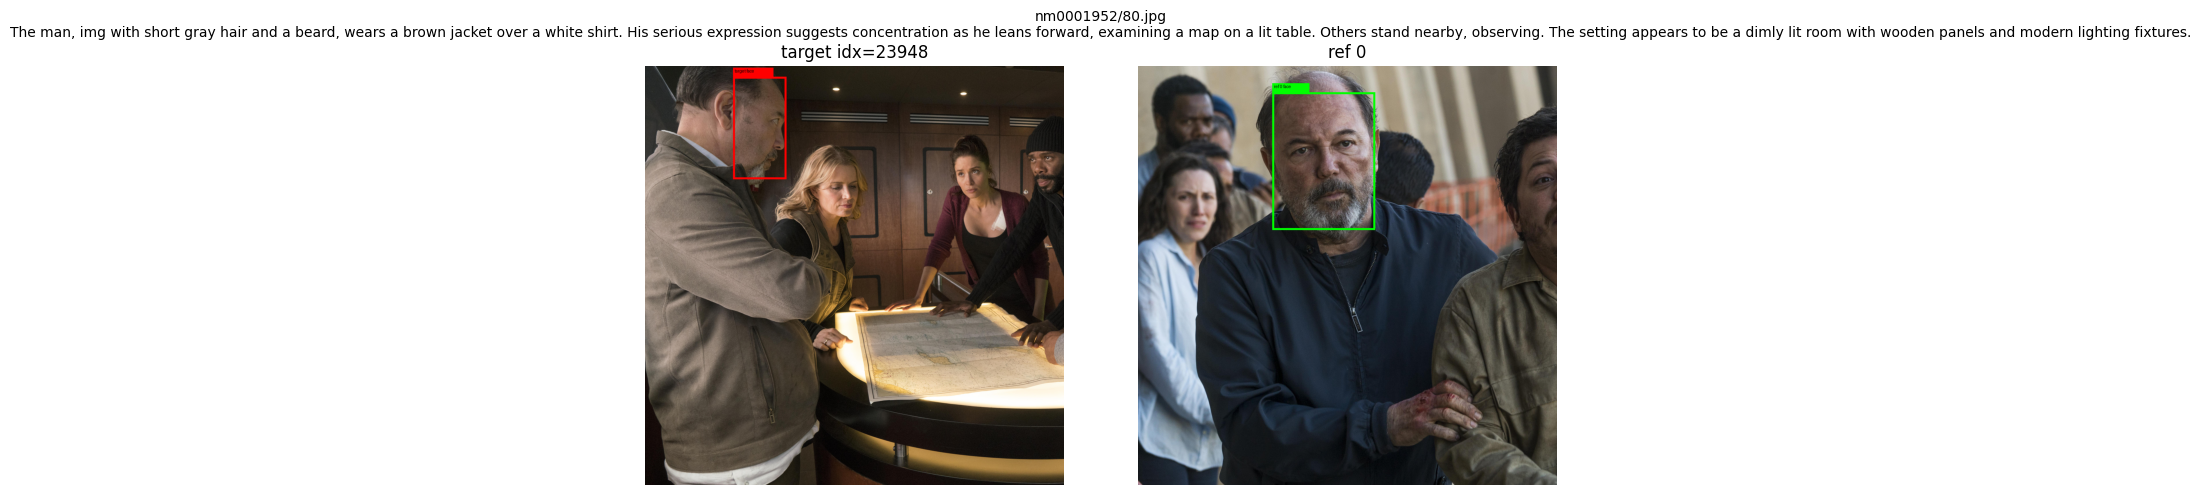

idx=7436
path: nm0000487/13.jpg
identity: nm0000487
prompt: A man img with short black hair, wearing a black shirt, holds a Golden Globe award. He smiles warmly, exuding pride and joy. The backdrop features "Golden Globe Awards" text and NBC logos, indicating a celebratory event. His posture is relaxed yet confident, highlighting his achievement.
pixel_values: (3, 1024, 1024)
face_bbox: [225, 81, 491, 446]
face_bbox_ref: [245, 65, 461, 378]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


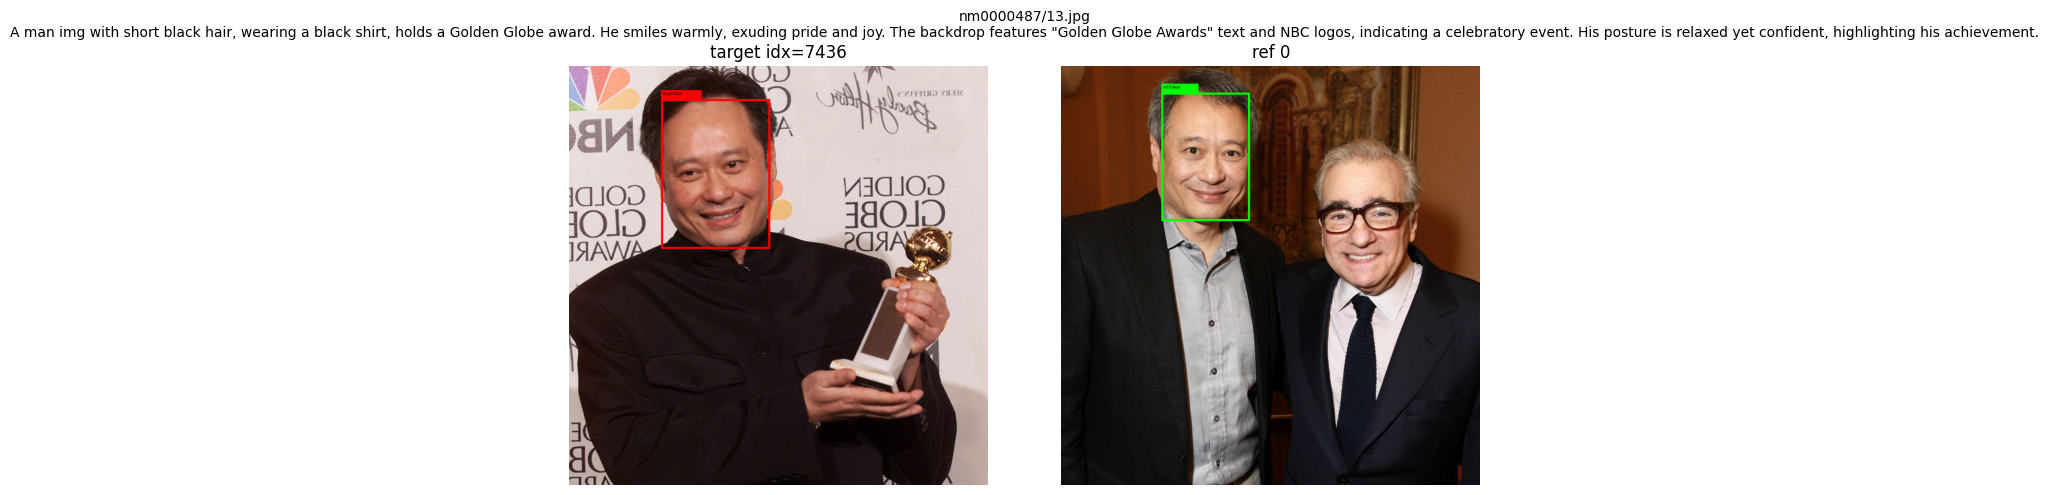

In [10]:
for idx in random_indices:
    print('=' * 120)
    show_item(idx, seed=BASE_SEED)

## Manual Single-Sample Inspection

idx=16664
path: nm0001459/180.jpg
identity: nm0001459
prompt: The person img at the center has spiky blonde hair, wears a black leather jacket, and sports a silver chain necklace. Their expression appears serious and focused. They stand upright, hands slightly raised, with others around. The setting seems to be indoors, possibly a dimly lit room with a rustic backdrop.
pixel_values: (3, 1024, 1024)
face_bbox: [429, 111, 565, 284]
face_bbox_ref: [352, 213, 614, 536]
ref image sizes: [(1024, 1024)]
keys: ['crop_top_lefts', 'face_bbox', 'face_bbox_ref', 'original_sizes', 'pixel_values', 'prompt', 'prompts', 'ref_images']


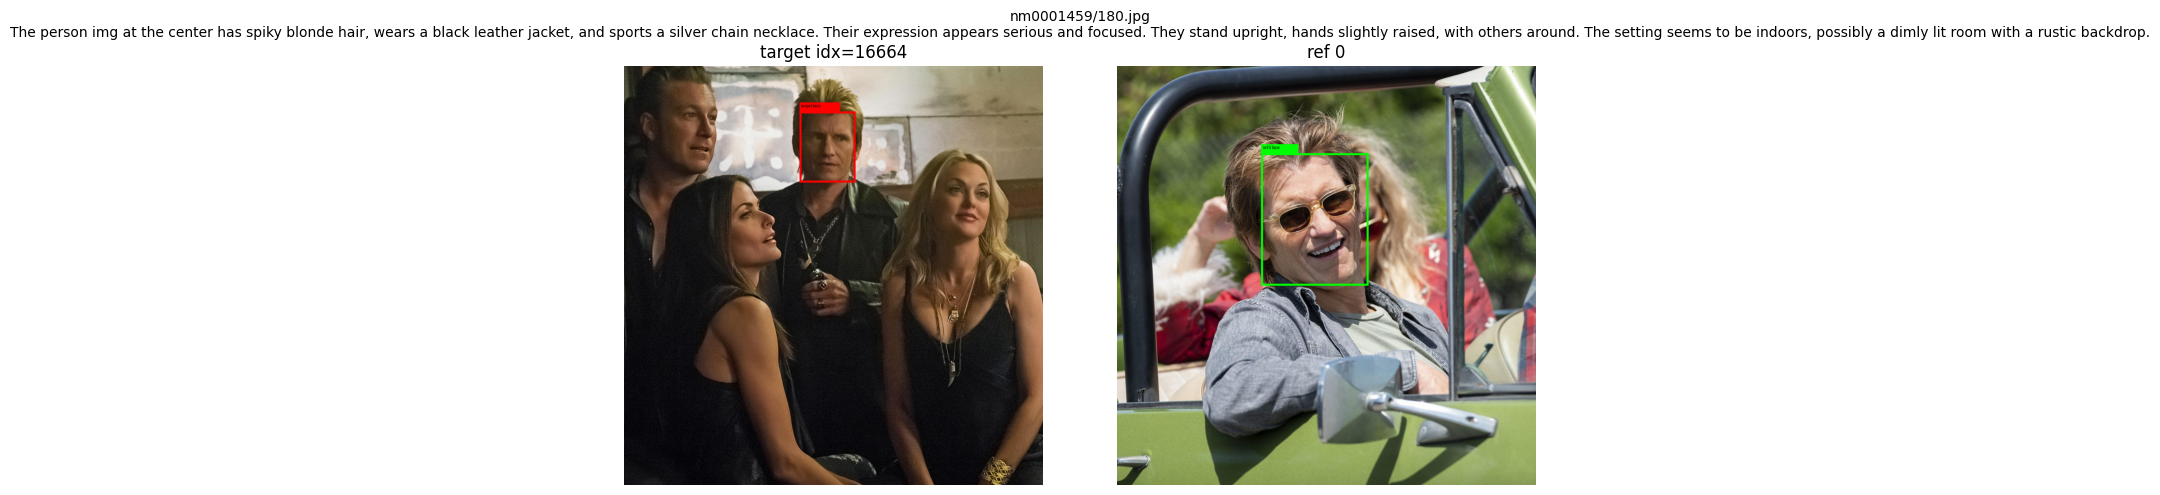

In [11]:
item = show_item(random_indices[0], seed=BASE_SEED)

## Collated Batch Fields

This is the structure passed to `model.forward` by the training DataLoader for `batch_size=1`.

In [12]:
def show_collated_batch(idx=random_indices[0], seed=BASE_SEED):
    item = get_item(idx, seed=seed)
    batch = collate_fn([item])
    print(f'collated batch idx={idx}')
    for key, value in batch.items():
        if torch.is_tensor(value):
            print(f'{key}: tensor shape={tuple(value.shape)} dtype={value.dtype}')
        elif isinstance(value, list):
            print(f'{key}: list len={len(value)} type0={type(value[0]).__name__ if value else None}')
            if key == 'ref_images' and value:
                refs0 = value[0] if isinstance(value[0], (list, tuple)) else [value[0]]
                print('  ref_images[0] count:', len(refs0))
                print('  ref_images[0] sizes:', [r.size if isinstance(r, Image.Image) else tuple(r.shape) for r in refs0])
        else:
            print(f'{key}: {type(value).__name__} {value}')
    return batch


batch = show_collated_batch()

collated batch idx=16664
pixel_values: tensor shape=(1, 3, 1024, 1024) dtype=torch.float32
face_bbox: list len=1 type0=list
face_bbox_ref: list len=1 type0=list
ref_images: list len=1 type0=list
  ref_images[0] count: 1
  ref_images[0] sizes: [(1024, 1024)]
prompts: list len=1 type0=str
prompt: list len=1 type0=str
original_sizes: list len=1 type0=tuple
crop_top_lefts: list len=1 type0=tuple


## Notes

- `pixel_values` is transformed exactly as in the training config: resized to 1024 and normalized to `[-1, 1]`.
- `ref_images` remain PIL images at dataset/collate time. They are consumed later by PhotoMaker's ID image processor and reference-latent path.
- With `TRAIN_ON_SEPARATE_IMAGE=False`, `LargeDatasetTrain` uses the target image as the reference and `face_bbox_ref == face_bbox` after any random horizontal flip.
- Set `TRAIN_ON_SEPARATE_IMAGE=True` near the top if you want to inspect the alternate path where the reference is sampled from another image of the same identity.